In [2]:
import sys
sys.path.append('LIBS')
#from LIBS.force_field import *
from LIBS.upgraded_ff import *
from LIBS.utils import *

dataset = get_dataset(scale_pos = False, return_pos_angstrom=False)

physics_critic = EnergyCalculator(
    pdb_file='../DATA/raw/protein_only.pdb',
    forcefield_files=['amber99sb.xml', 'tip3p.xml'])


energy_list = []
openmm_energy_list = []

for data in dataset:
    pos = data['pos']

    energy = physics_critic(pos)
    openmm_energy = physics_critic.openMM_energy(pos)
   

    energy_list.append(energy)
    openmm_energy_list.append(openmm_energy)


Loading dataset ...
Root directory: None
TPR file: MD.tpr
Trajectory file: MD_with_solvent_noPBC.xtc
Selection: protein
Include atom type: True
Scale features: True
Scale positions: False
Initial alignment: False
Return max position: False
Return position in Angstrom: False
No root directory provided, using default path ...
Successfully loaded processed data from /home/clod/Desktop/THESIS_2/FULL_ATOM/DATA/processed/data_MD_protein.pt
Converting positions to nm ...
Positions shape: torch.Size([20032, 52, 3])
Including atom features: performing one hot encoding ...
Scaling features ...
not aligning the frames ...
Dataset created with 20032 graphs.
Number of graphs in the dataset: 20032
Number of features in the dataset: 6
Number of edges in the dataset: 102
Number of nodes in the dataset: 52
Number of features in the dataset: torch.Size([52, 6])

Using OpenMM platform: CUDA


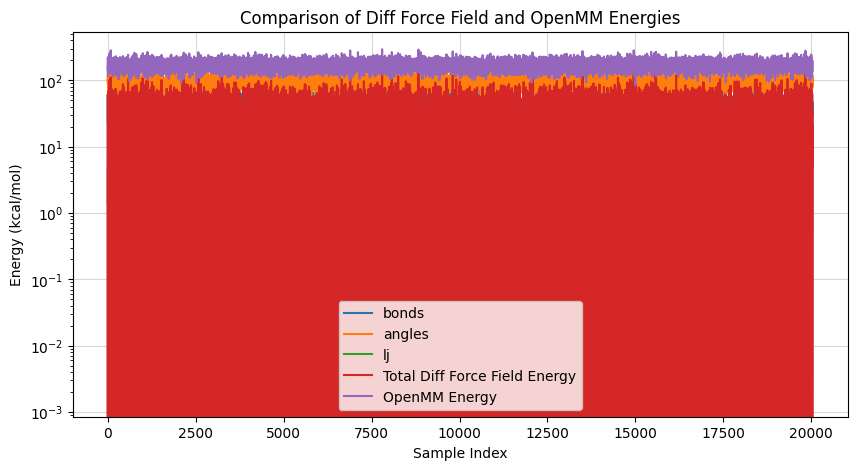

In [7]:

total_energy_list =  [e[0] + e[1] + e[2] for e in energy_list]
#[5*a[0] + 2*a[1] + 0.01*a[2] for a in energy_list]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(energy_list, label=['bonds','angles','lj'])
plt.plot(total_energy_list, label='Total Diff Force Field Energy')
plt.plot(openmm_energy_list, label='OpenMM Energy')
plt.xlabel('Sample Index')
plt.ylabel('Energy (kcal/mol)')
plt.yscale('log')
plt.title('Comparison of Diff Force Field and OpenMM Energies')
plt.grid(alpha=0.5)
plt.legend()
plt.show()  

In [4]:
print(f"Mean Diff Force Field Energy: {np.mean(total_energy_list):.2e} kcal/mol")

print(f"Mean bonds Energy: {np.mean([energy_list[i][0] for i in range(len(energy_list))]):.2e} kcal/mol")
print(f"Mean angles Energy: {np.mean([energy_list[i][1] for i in range(len(energy_list))]):.2e} kcal/mol")
print(f"Mean lj Energy: {np.mean([energy_list[i][2] for i in range(len(energy_list))]):.2e} kcal/mol")
print(f"Mean OpenMM Energy: {np.mean(openmm_energy_list):.2e} kcal/mol")




Mean Diff Force Field Energy: 3.72e+02 kcal/mol
Mean bonds Energy: 3.69e+01 kcal/mol
Mean angles Energy: 9.44e+01 kcal/mol
Mean lj Energy: -1.10e+02 kcal/mol
Mean OpenMM Energy: 1.71e+02 kcal/mol


In [16]:
# --- Let's run the other energy terms ---

# Assuming 'energy_calc' and 'coords_tensor' are loaded from the previous step

coords_tensor = torch.tensor(dataset[0]['pos'], dtype=torch.float32)

energy_calc = EnergyCalculator(
    pdb_file='../DATA/raw/protein_only.pdb',
    forcefield_files=['amber99sb.xml', 'tip3p.xml'],
    add_hydrogens=False,  # Assuming no hydrogens are needed for this
    prefer_gpu=True)  
# Calculate Bond Energy
pytorch_bond_energy = energy_calc.harmonic_bond_energy(coords_tensor)

# Calculate Angle Energy
pytorch_angle_energy = energy_calc.angle_energy(coords_tensor)

# Get the Non-Bonded Energy we already calculated
pytorch_nonbonded_energy = energy_calc.nonbonded_energy(coords_tensor)

# --- Sum them up ---
total_pytorch_energy = pytorch_bond_energy + pytorch_angle_energy + pytorch_nonbonded_energy

print(f"Pytorch Bond Energy:   {pytorch_bond_energy.item():.4f} kJ/mol")
print(f"Pytorch Angle Energy:  {pytorch_angle_energy.item():.4f} kJ/mol")
print("------------------------------------------")
print(f"Pytorch Non-Bonded Energy: {pytorch_nonbonded_energy.item():.4f} kJ/mol")
print("------------------------------------------")
print(f"Total PyTorch Energy:    {total_pytorch_energy.item():.4f} kJ/mol")

# For comparison, let's get the total energy from OpenMM
unbounded_energy_openMM = energy_calc.openMM_nonbonded_energy(coords_tensor)  # Assuming this is the non-bonded energy
print(f"Unbounded Non-Bonded Energy: {unbounded_energy_openMM:.4f} kJ/mol")
total_openmm_energy = energy_calc.openMM_energy(coords_tensor) # A new helper function
print(f"Total OpenMM Energy:     {total_openmm_energy:.4f} kJ/mol")

/tmp/ipykernel_160690/2946465304.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords_tensor = torch.tensor(dataset[0]['pos'], dtype=torch.float32)


Using OpenMM platform: CUDA
Pytorch Bond Energy:   1.3928 kJ/mol
Pytorch Angle Energy:  99.4721 kJ/mol
------------------------------------------
Pytorch Non-Bonded Energy: -122.9262 kJ/mol
------------------------------------------
Total PyTorch Energy:    -22.0613 kJ/mol
Unbounded Non-Bonded Energy: -122.9224 kJ/mol
Total OpenMM Energy:     117.9824 kJ/mol
